# CSCI E-89 Deep Learning, Assignment 03, Problem 4

**Name:** Andra Constandache  
**Tool:** OpenAI Codex  
**Repository:** https://github.com/andraconsta/e89-hw03/tree/main/wk3-codex

| Notebook section | Source script |
|---|---|
| 1 | `data.py` |
| 2 | `classifier.py` |
| 3 | `training.py` |
| 4 | `accuracy_plot.py` |
| 5 | `inference.py` |

## data.py

Load FashionMNIST with the template transforms, create the seeded training/validation split, and build the three batch loaders. The cell prints split sizes and sample/batch shapes.

In [1]:
# ===== Script: data.py =====
"""Load FashionMNIST and create reproducible data splits and mini-batches."""
import torch
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

# Convert each grayscale PIL image to a float tensor scaled to [0, 1].
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Load the 60,000-image training set and the separate 10,000-image test set.
train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

# Split training data into 55,000 training examples and 5,000 validation examples.
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

# Build batch-size-32 loaders and shuffle only the training examples.
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

if __name__ == "__main__":
    # Print split sizes, a sample, and a batch to verify the input pipeline.
    print(f"Train: {len(train_data)}")
    print(f"Valid: {len(valid_data)}")
    print(f"Test:  {len(test_data)}")
    X_sample, y_sample = train_data[0]
    print(f"Sample image: {X_sample.shape}, dtype {X_sample.dtype}")
    print(f"Sample class: {train_and_valid_data.classes[y_sample]}")
    X_batch, y_batch = next(iter(train_loader))
    print(f"Batch images: {X_batch.shape}, dtype {X_batch.dtype}")
    print(f"Batch labels: {y_batch.shape}")


Train: 55000
Valid: 5000
Test:  10000
Sample image: torch.Size([1, 28, 28]), dtype torch.float32
Sample class: Ankle boot
Batch images: torch.Size([32, 1, 28, 28]), dtype torch.float32
Batch labels: torch.Size([32])


## classifier.py

Select an available compute device and define the template MLP. The cell reports architecture, parameter count, logits shape, and initial loss.

In [2]:
# ===== Script: classifier.py =====
"""Define Geron's FashionMNIST MLP and choose an available compute device."""
import torch
import torch.nn as nn

# Prefer NVIDIA CUDA, then Apple MPS, and otherwise keep execution on the CPU.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Flatten 28x28 grayscale images, learn two hidden representations, and output 10 logits.
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

if __name__ == "__main__":
    # Import one training batch, seed initialization, and build the chapter-sized model.
    # from data import train_loader  # Defined by preceding data.py cell.
    torch.manual_seed(42)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300,
                            n_hidden2=100, n_classes=10).to(device)
    xentropy = nn.CrossEntropyLoss()

    # Print the model, parameter count, logits shape, and initial loss for validation.
    print(f"Device: {device}")
    print(model)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")
    X_batch, y_batch = next(iter(train_loader))
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    with torch.no_grad():
        logits = model(X_batch)
    print(f"Logits shape: {logits.shape}")
    print(f"Initial loss: {xentropy(logits, y_batch).item():.4f}")


Device: cuda
ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610
Logits shape: torch.Size([32, 10])
Initial loss: 2.3156


## training.py

Train the classifier for 20 epochs with SGD and multiclass accuracy. The cell prints epoch metrics and saves weights and metric history.

In [3]:
# ===== Script: training.py =====
"""Train and evaluate the FashionMNIST classifier with Geron's helpers."""
import json
import torch
import torch.nn as nn
import torchmetrics
# from data import train_loader, valid_loader  # Defined by data.py cell.
# from classifier import ImageClassifier, device  # Defined by classifier.py cell.

# Evaluate a model on a complete data loader without computing gradients.
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

# Train with mini-batches, recording average loss and train/validation accuracy each epoch.
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"validation accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

if __name__ == "__main__":
    # Seed and initialize the Geron model, cross-entropy objective, SGD, and accuracy metric.
    n_epochs = 20
    torch.manual_seed(42)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300,
                            n_hidden2=100, n_classes=10).to(device)
    xentropy = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

    # Train for all epochs and preserve model weights and the complete metric history.
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs)
    torch.save(model.state_dict(), "model_weights.pt")
    with open("train_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)
    print("Saved model_weights.pt and train_history.json")


Epoch 1/20, train loss: 0.6059, train accuracy: 0.7810, validation accuracy: 0.8426
Epoch 2/20, train loss: 0.4057, train accuracy: 0.8501, validation accuracy: 0.8392
Epoch 3/20, train loss: 0.3629, train accuracy: 0.8659, validation accuracy: 0.8556
Epoch 4/20, train loss: 0.3352, train accuracy: 0.8770, validation accuracy: 0.8642
Epoch 5/20, train loss: 0.3144, train accuracy: 0.8843, validation accuracy: 0.8774
Epoch 6/20, train loss: 0.2996, train accuracy: 0.8870, validation accuracy: 0.8626
Epoch 7/20, train loss: 0.2852, train accuracy: 0.8921, validation accuracy: 0.8774
Epoch 8/20, train loss: 0.2749, train accuracy: 0.8966, validation accuracy: 0.8746
Epoch 9/20, train loss: 0.2641, train accuracy: 0.9009, validation accuracy: 0.8810
Epoch 10/20, train loss: 0.2540, train accuracy: 0.9027, validation accuracy: 0.8766
Epoch 11/20, train loss: 0.2463, train accuracy: 0.9065, validation accuracy: 0.8848
Epoch 12/20, train loss: 0.2367, train accuracy: 0.9099, validation accura

## accuracy_plot.py

Read the saved history and plot training accuracy across epochs, including labels, grid, legend, and final value annotation.

Saved accuracy_plot.png


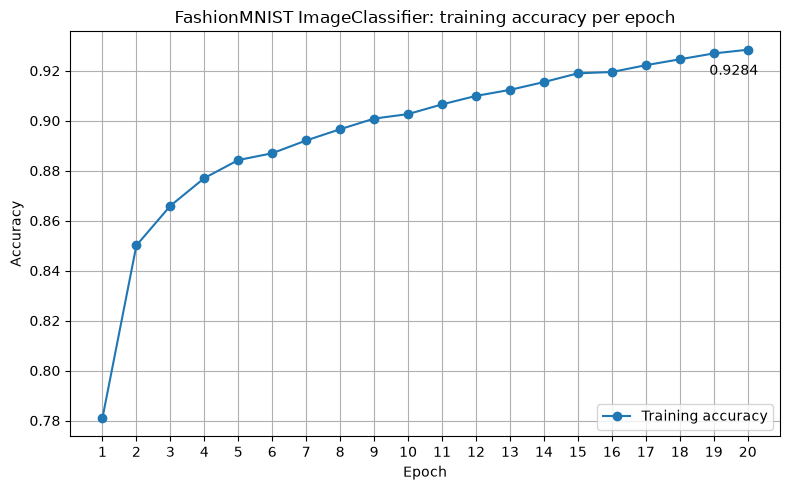

In [4]:
# ===== Script: accuracy_plot.py =====
"""Plot training accuracy across the 20 recorded epochs."""
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the training accuracies saved by training.py.
with open("train_history.json", encoding="utf-8") as f:
    history = json.load(f)
train_accuracy = np.asarray(history["train_metrics"])
epochs = np.arange(1, len(train_accuracy) + 1)

# Draw the learning curve, annotate its final value, and label each epoch.
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, "o-", label="Training accuracy")
plt.annotate(f"{train_accuracy[-1]:.4f}",
             xy=(epochs[-1], train_accuracy[-1]),
             xytext=(-10, -18), textcoords="offset points", ha="center")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST ImageClassifier: training accuracy per epoch")
plt.xticks(epochs)
plt.grid(True)
plt.legend(loc="lower right")
plt.tight_layout()

# Save the requested figure and display it for inspection.
plt.savefig("accuracy_plot.png", dpi=150)
print("Saved accuracy_plot.png")
plt.show()


## inference.py

Load trained weights and classify the first three validation images. The cell prints predictions, true labels, confidence and displays all three images.

Predicted class names: ['Sneaker', 'Coat', 'Pullover']
True class names:      ['Sneaker', 'Coat', 'Pullover']
Image 1: predicted Sneaker (85.9% confidence), true Sneaker -> correct
Image 2: predicted Coat (99.6% confidence), true Coat -> correct
Image 3: predicted Pullover (80.9% confidence), true Pullover -> correct
Saved inference.png


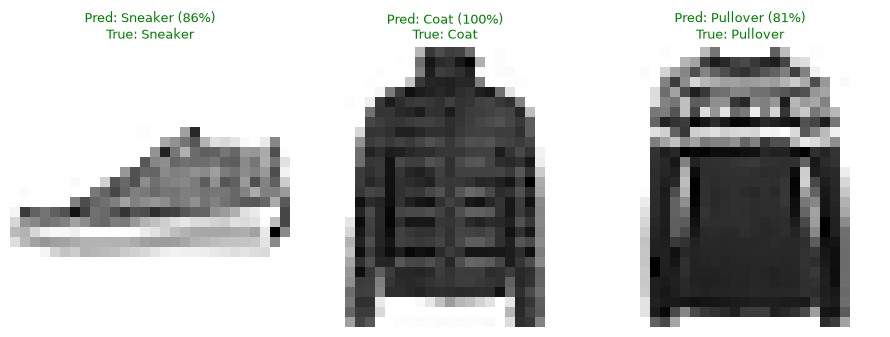

In [5]:
# ===== Script: inference.py =====
"""Predict FashionMNIST classes for three validation images."""
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
# from data import train_and_valid_data, valid_loader  # Defined by data.py cell.
# from classifier import ImageClassifier, device  # Defined by classifier.py cell.

# Rebuild the trained architecture, load weights, and enable inference mode.
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300,
                        n_hidden2=100, n_classes=10).to(device)
model.load_state_dict(torch.load("model_weights.pt", map_location=device))
model.eval()

# Take the first three validation images and predict without gradient tracking.
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
class_names = train_and_valid_data.classes

# Print each predicted class, the matching true class, and predicted confidence.
print("Predicted class names:", [class_names[i] for i in y_pred.tolist()])
print("True class names:     ", [class_names[i] for i in y_new.tolist()])
for i, (pred, true) in enumerate(zip(y_pred.tolist(), y_new.tolist())):
    verdict = "correct" if pred == true else "WRONG"
    print(f"Image {i + 1}: predicted {class_names[pred]} "
          f"({y_proba[i, pred]:.1%} confidence), true {class_names[true]} "
          f"-> {verdict}")

# Show all three images with predicted labels, confidence, and true labels.
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for i, ax in enumerate(axes):
    pred, true = y_pred[i].item(), y_new[i].item()
    ax.imshow(X_new[i].cpu().squeeze(), cmap="binary")
    ax.set_title(f"Pred: {class_names[pred]} ({y_proba[i, pred]:.0%})\n"
                 f"True: {class_names[true]}",
                 color="green" if pred == true else "red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("inference.png", dpi=150)
print("Saved inference.png")
plt.show()
